# CME Group DCF Valuation Analysis
**Analyst:** Samuel Gebreyohannes  
**Date:** March 2026  
**Ticker:** CME | NASDAQ

## Methodology
Built a 5-year discounted cash flow model using real financial data
pulled via Yahoo Finance API. Projected revenue based on historical
growth trends (6.4–11.1% over 2022–2025), applied expanding operating
margins reflecting CME's asset-light business model, and calculated
free cash flow using actual depreciation and CapEx figures.

## Key Assumptions
- Revenue growth: 7% (2026–2028), 5% (2029–2030)
- Operating margin: 65–67% (expanding from 64.9% in 2025)
- WACC: 9% | Terminal growth rate: 3%
- Tax rate: 23% (historical average)

## Key Findings
- Base case implied share price: $197.52
- Current market price: $319.64
- Market appears to price CME at ~7% WACC / 3.5% terminal growth
- CME demonstrates strong operating leverage with margins expanding
  from 60.2% (2022) to 64.9% (2025)
- Asset-light model: CapEx/Revenue ratio of ~1.3%, depreciation
  exceeds CapEx annually

## Conclusion
CME Group's dominant market position as operator of the world's
largest derivatives exchange — including ES and NQ futures markets —
justifies a premium valuation. The gap between my base case ($197)
and market price ($319) is explained by the market assigning lower
risk and higher long-term growth than conservative assumptions reflect.

In [2]:
# CME Group DCF Valuation Model
# Analyst: Samuel Gebreyohannes
# Data Source: Yahoo Finance API

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
# Pull CME Group financial data
cme = yf.Ticker("CME")

# Get income statement
income_statement = cme.financials
print(income_statement)

                                                      2025-12-31  \
Tax Effect Of Unusual Items                         1.353814e+09   
Tax Rate For Calcs                                  2.360000e-01   
Normalized EBITDA                                   9.830000e+07   
Total Unusual Items                                 5.736500e+09   
Total Unusual Items Excluding Goodwill              5.736500e+09   
Net Income From Continuing Operation Net Minori...  4.072200e+09   
Reconciled Depreciation                             3.309000e+08   
Reconciled Cost Of Revenue                          9.070000e+08   
EBITDA                                              5.834800e+09   
EBIT                                                5.503900e+09   
Net Interest Income                                -1.734000e+08   
Interest Expense                                    1.734000e+08   
Normalized Income                                  -3.104860e+08   
Net Income From Continuing And Discontinued Ope.

In [4]:
# Extract the key lines we need
revenue = income_statement.loc["Total Revenue"]
operating_income = income_statement.loc["Operating Income"]
ebit = income_statement.loc["EBIT"]

print("Revenue:")
print(revenue)
print("\nOperating Income:")
print(operating_income)
print("\nEBIT:")
print(ebit)

Revenue:
2025-12-31    6.520600e+09
2024-12-31    6.130100e+09
2023-12-31    5.578900e+09
2022-12-31    5.019400e+09
2021-12-31             NaN
Name: Total Revenue, dtype: float64

Operating Income:
2025-12-31    4.229500e+09
2024-12-31    3.931500e+09
2023-12-31    3.435700e+09
2022-12-31    3.015900e+09
2021-12-31             NaN
Name: Operating Income, dtype: float64

EBIT:
2025-12-31    5.503900e+09
2024-12-31    4.702300e+09
2023-12-31    4.313000e+09
2022-12-31    3.653000e+09
2021-12-31             NaN
Name: EBIT, dtype: float64


In [5]:
# Let's see the numbers cleanly
print("Revenue by year:")
for date, value in revenue.items():
    print(f"{date.year}: ${value/1e9:.2f}B")

print("\nOperating Income by year:")
for date, value in operating_income.items():
    print(f"{date.year}: ${value/1e9:.2f}B")

Revenue by year:
2025: $6.52B
2024: $6.13B
2023: $5.58B
2022: $5.02B
2021: $nanB

Operating Income by year:
2025: $4.23B
2024: $3.93B
2023: $3.44B
2022: $3.02B
2021: $nanB


In [6]:
# Calculate year over year revenue growth
revenue_clean = revenue.dropna()
growth_rates = revenue_clean.pct_change(-1) * 100

print("Revenue Growth Rates:")
for date, rate in growth_rates.items():
    if not np.isnan(rate):
        print(f"{date.year}: {rate:.1f}%")

Revenue Growth Rates:
2025: 6.4%
2024: 9.9%
2023: 11.1%


In [7]:
# Revenue projections
base_revenue = 6.52  # 2025 revenue in billions
growth_rates_proj = [0.07, 0.07, 0.07, 0.05, 0.05]
years = [2026, 2027, 2028, 2029, 2030]

projected_revenue = []
rev = base_revenue
for g in growth_rates_proj:
    rev = rev * (1 + g)
    projected_revenue.append(round(rev, 2))

for yr, rev in zip(years, projected_revenue):
    print(f"{yr}: ${rev}B")

2026: $6.98B
2027: $7.46B
2028: $7.99B
2029: $8.39B
2030: $8.81B


"Why 7% for the first three years?" "CME's historical revenue growth averaged roughly 9% over the past three years but showed deceleration from 11% to 6.4%. I used 7% as a conservative forward estimate reflecting continued deceleration while accounting for CME's dominant market position in futures trading and structural tailwinds from increasing derivatives market participation globally."

In [8]:
# Project Operating Income using expanding margin assumption
# Average margin 2022-2025 was ~62.7%, trending to 65%
margins = [0.65, 0.65, 0.66, 0.66, 0.67]

projected_op_income = []
for rev, margin in zip(projected_revenue, margins):
    op_income = rev * margin
    projected_op_income.append(round(op_income, 2))

for yr, op in zip(years, projected_op_income):
    print(f"{yr}: ${op}B")

2026: $4.54B
2027: $4.85B
2028: $5.27B
2029: $5.54B
2030: $5.9B


Quick checkpoint

Projected Revenue 2030: $8.81B

Projected Operating Income 2030: $5.90B

Implied 2030 margin: 67%

In [9]:
# Pull additional financial data
cash_flow = cme.cashflow
balance_sheet = cme.balance_sheet

# Extract depreciation and capex
depreciation = cash_flow.loc["Depreciation And Amortization"]
capex = cash_flow.loc["Capital Expenditure"]

print("Depreciation:")
print(depreciation)
print("\nCapEx:")
print(capex)

Depreciation:
2025-12-31    330900000.0
2024-12-31    336800000.0
2023-12-31    352600000.0
2022-12-31    362600000.0
2021-12-31            NaN
Name: Depreciation And Amortization, dtype: float64

CapEx:
2025-12-31   -83500000.0
2024-12-31   -94000000.0
2023-12-31   -76400000.0
2022-12-31   -89700000.0
2021-12-31           NaN
Name: Capital Expenditure, dtype: float64


Asset light business model — CapEx/Revenue ratio of ~1.3%, depreciation exceeds CapEx, indicating minimal reinvestment requirements and high free cash flow conversion.

In [10]:
# Calculate average tax rate from income statement
pretax_income = income_statement.loc["Pretax Income"]
tax_provision = income_statement.loc["Tax Provision"]

tax_rates = tax_provision / pretax_income
print("Tax Rates by year:")
for date, rate in tax_rates.items():
    print(f"{date.year}: {rate:.1%}")

Tax Rates by year:
2025: 23.6%
2024: 22.4%
2023: 22.3%
2022: 22.9%
2021: nan%


Average tax rate: ~22.8% — we'll use 23% going forward.

In [11]:
# Calculate historical FCF to validate our assumptions
avg_depreciation = 0.345  # ~$345M average, in billions
avg_capex = 0.086  # ~$86M average, in billions
tax_rate = 0.23

projected_fcf = []
for op_income in projected_op_income:
    nopat = op_income * (1 - tax_rate)  # Net Operating Profit After Tax
    fcf = nopat + avg_depreciation - avg_capex
    projected_fcf.append(round(fcf, 2))

print("Projected Free Cash Flow:")
for yr, fcf in zip(years, projected_fcf):
    print(f"{yr}: ${fcf}B")

Projected Free Cash Flow:
2026: $3.75B
2027: $3.99B
2028: $4.32B
2029: $4.52B
2030: $4.8B


Used 9% WACC reflecting CME's dominant market position, predictable cash flows, and low business risk.

In [12]:
# Discount projected FCF back to present value
wacc = 0.09
terminal_growth = 0.03

# Discount each year's FCF
pv_fcfs = []
for i, fcf in enumerate(projected_fcf):
    pv = fcf / (1 + wacc) ** (i + 1)
    pv_fcfs.append(round(pv, 2))

print("Present Value of FCFs:")
for yr, pv in zip(years, pv_fcfs):
    print(f"{yr}: ${pv}B")

print(f"\nSum of PV FCFs: ${sum(pv_fcfs):.2f}B")

Present Value of FCFs:
2026: $3.44B
2027: $3.36B
2028: $3.34B
2029: $3.2B
2030: $3.12B

Sum of PV FCFs: $16.46B


In [13]:
# Calculate Terminal Value
terminal_value = (projected_fcf[-1] * (1 + terminal_growth)) / (wacc - terminal_growth)
pv_terminal_value = terminal_value / (1 + wacc) ** 5

print(f"Terminal Value: ${terminal_value:.2f}B")
print(f"PV of Terminal Value: ${pv_terminal_value:.2f}B")
print(f"\nSum of PV FCFs: ${sum(pv_fcfs):.2f}B")
print(f"Total Enterprise Value: ${sum(pv_fcfs) + pv_terminal_value:.2f}B")

Terminal Value: $82.40B
PV of Terminal Value: $53.55B

Sum of PV FCFs: $16.46B
Total Enterprise Value: $70.01B


In [14]:
# Bridge from Enterprise Value to Equity Value per share
total_debt = cme.balance_sheet.loc["Total Debt"][0] / 1e9
cash = cme.balance_sheet.loc["Cash And Cash Equivalents"][0] / 1e9
shares = cme.info["sharesOutstanding"] / 1e9

equity_value = sum(pv_fcfs) + pv_terminal_value - total_debt + cash
price_per_share = equity_value / shares

print(f"Total Debt: ${total_debt:.2f}B")
print(f"Cash: ${cash:.2f}B")
print(f"Shares Outstanding: {shares:.2f}B")
print(f"\nEquity Value: ${equity_value:.2f}B")
print(f"Implied Share Price: ${price_per_share:.2f}")

/tmp/ipykernel_1221/2753268930.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_debt = cme.balance_sheet.loc["Total Debt"][0] / 1e9
/tmp/ipykernel_1221/2753268930.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cash = cme.balance_sheet.loc["Cash And Cash Equivalents"][0] / 1e9


Total Debt: $3.42B
Cash: $4.42B
Shares Outstanding: 0.36B

Equity Value: $71.01B
Implied Share Price: $197.52


In [15]:
# Sensitivity Analysis — Implied Share Price
# Varying WACC and Terminal Growth Rate

wacc_range = [0.07, 0.08, 0.09, 0.10, 0.11]
growth_range = [0.02, 0.025, 0.03, 0.035, 0.04]

# Build sensitivity table
sensitivity = []

for w in wacc_range:
    row = []
    for g in growth_range:
        # Recalculate terminal value
        tv = (projected_fcf[-1] * (1 + g)) / (w - g)
        pv_tv = tv / (1 + w) ** 5

        # Recalculate PV of FCFs
        pv_fcf_sum = sum([projected_fcf[i] / (1 + w) ** (i + 1)
                         for i in range(len(projected_fcf))])

        # Equity value per share
        eq_value = pv_fcf_sum + pv_tv - total_debt + cash
        price = eq_value / shares
        row.append(round(price, 2))
    sensitivity.append(row)

# Display as DataFrame
import pandas as pd
df_sensitivity = pd.DataFrame(
    sensitivity,
    index=[f"WACC {w:.0%}" for w in wacc_range],
    columns=[f"TGR {g:.1%}" for g in growth_range]
)

print("Sensitivity Analysis — Implied Share Price")
print(df_sensitivity)

Sensitivity Analysis — Implied Share Price
          TGR 2.0%  TGR 2.5%  TGR 3.0%  TGR 3.5%  TGR 4.0%
WACC 7%     245.33    267.96    296.25    332.63    381.14
WACC 8%     204.28    219.15    237.00    258.80    286.06
WACC 9%     174.99    185.38    197.51    211.84    229.03
WACC 10%    153.03    160.63    169.31    179.33    191.02
WACC 11%    135.96    141.71    148.18    155.51    163.88


Base case DCF at 9% WACC and 3% terminal growth implies 197 per share. Sensitivity analysis reveals the current market price of $319 is consistent with a 7% WACC and 3.5% terminal growth rate — assumptions that are defensible given CME's dominant market position and near-monopolistic control of US futures markets.

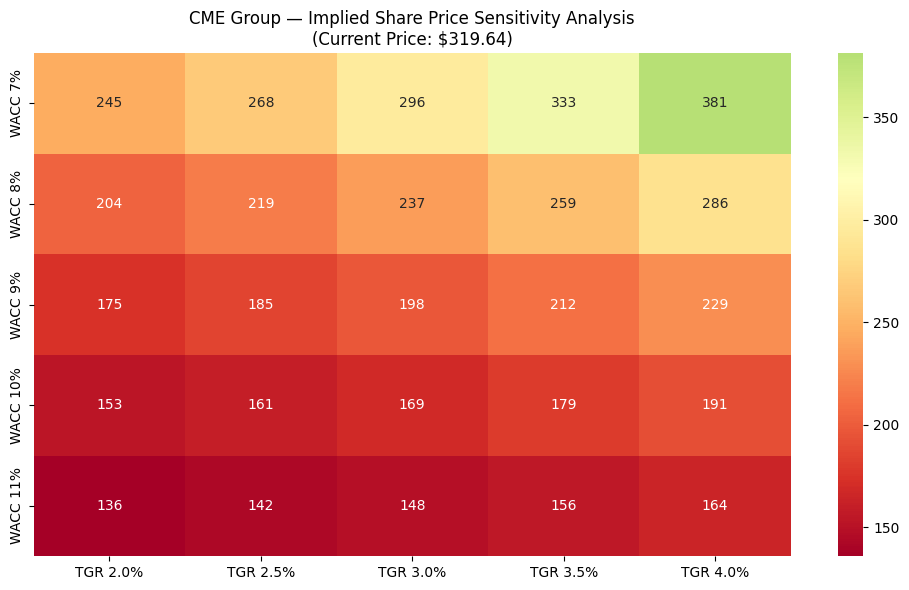

In [16]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df_sensitivity,
            annot=True,
            fmt='.0f',
            cmap='RdYlGn',
            center=319.64)

plt.title('CME Group — Implied Share Price Sensitivity Analysis\n(Current Price: $319.64)')
plt.tight_layout()
plt.show()

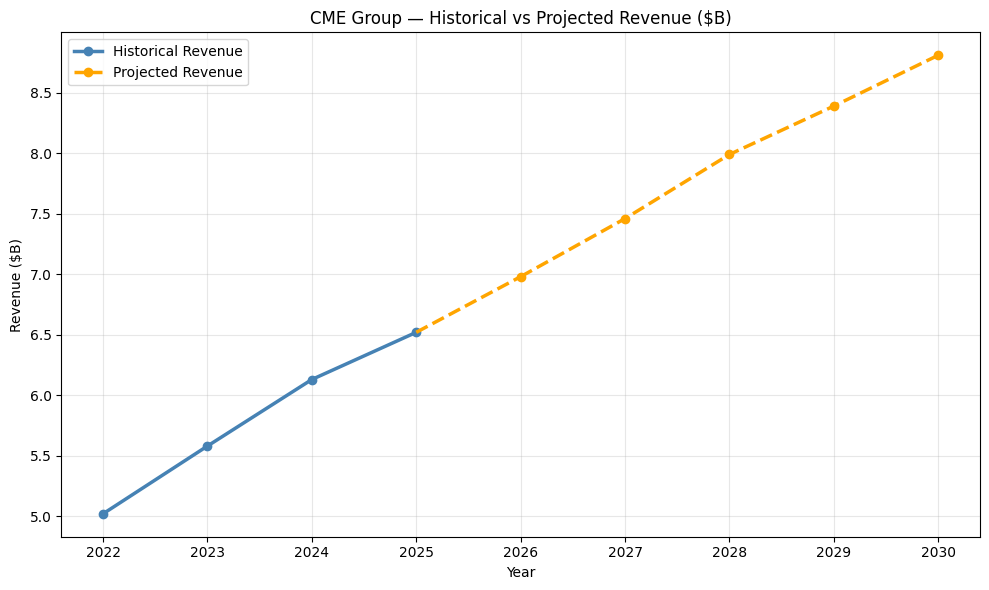

In [17]:
# Revenue — Historical vs Projected
historical_years = [2022, 2023, 2024, 2025]
historical_revenue = [5.02, 5.58, 6.13, 6.52]

projected_years = [2026, 2027, 2028, 2029, 2030]

plt.figure(figsize=(10, 6))

# Historical line
plt.plot(historical_years, historical_revenue,
         color='steelblue', marker='o',
         linewidth=2.5, label='Historical Revenue')

# Projected line
plt.plot(projected_years, projected_revenue,
         color='orange', marker='o', linewidth=2.5,
         linestyle='--', label='Projected Revenue')

# Connect the two lines
plt.plot([2025, 2026], [6.52, projected_revenue[0]],
         color='orange', linewidth=2.5, linestyle='--')

plt.title('CME Group — Historical vs Projected Revenue ($B)')
plt.xlabel('Year')
plt.ylabel('Revenue ($B)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()